# Diabetes 30-Day Readmission Analysis
## - by Samuel Onewo, RN, MSDS (Clinical Data Scientist)

In [28]:
#Let's import libraries here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Data Loading & Wrangling

In [26]:
def wrangle(filepath):
    """
    This function loads and prepares the diabetes readmission data for analysis.
    
    Then Returns:
        df: Cleaned dataframe with binary readmit_30 target
    """
    # Read the file path into a dataframe
    df = pd.read_csv(filepath)
    
    # Make a copy of the df
    df_copy = df.copy()
    
    # Replace '?' with NaN in the dataframe
    df_copy.replace('?', np.nan, inplace=True)
    
    # Columns that need to be kept
    cols_to_keep = ['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'A1Cresult', 'max_glu_serum', 'change', 'diabetesMed', 'readmitted']
    
    df = df_copy[cols_to_keep]
    
    return df

In [3]:
df = wrangle('icu_diabetes/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,diag_3,number_diagnoses,number_outpatient,number_emergency,number_inpatient,A1Cresult,max_glu_serum,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,NaN,1,0,0,0,NaN,NaN,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,255,9,0,0,0,NaN,NaN,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,V27,6,2,0,1,NaN,NaN,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,403,7,0,0,0,NaN,NaN,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,250,5,0,0,0,NaN,NaN,Ch,Yes,NO


## 2. Exploratory Data Analysis

In [5]:
# 1. Check missingness in your cleaned data
df.isnull().sum()
#If you check the proportion of missing values you'll see it's not much
df.isnull().sum()/len(df)

encounter_id                0.000000
patient_nbr                 0.000000
race                        0.022336
gender                      0.000000
age                         0.000000
admission_type_id           0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
num_lab_procedures          0.000000
num_procedures              0.000000
num_medications             0.000000
diag_1                      0.000206
diag_2                      0.003518
diag_3                      0.013983
number_diagnoses            0.000000
number_outpatient           0.000000
number_emergency            0.000000
number_inpatient            0.000000
A1Cresult                   0.832773
max_glu_serum               0.947468
change                      0.000000
diabetesMed                 0.000000
readmitted                  0.000000
dtype: float64

In [6]:
print(df.shape)
df.info()

(101766, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  diag_1                    101745 non-null  object
 13  diag_2                    101408 non-null  obj

In [7]:
#Any duplocate data on the patients and encounter side?
print(f"Unique patients: {df['patient_nbr'].nunique()}")
print(f"Unique encounters: {df['encounter_id'].nunique()}")
print(f"Total encounters: {len(df)}")

Unique patients: 71518
Unique encounters: 101766
Total encounters: 101766


### 2.1 Target Variable Distribution

In [8]:
#Lets understand the target variable
df['readmitted'].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

In [9]:
#columns_Inpt = ['readmitted']
df['readmit_30'] = (df['readmitted']=='<30').astype(int)
df['readmit_30'].value_counts()

readmit_30
0    90409
1    11357
Name: count, dtype: int64

### 2.2 Correlation Analysis

In [10]:
# Correlation with your new binary target
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_diagnoses', 'number_outpatient', 
                'number_emergency', 'number_inpatient', 'readmit_30']

correlation_matrix = df[numeric_cols].corr()

# Look specifically at what correlates with 30-day readmission
readmission_corr = correlation_matrix['readmit_30'].sort_values(ascending=False)
print("\nCorrelations with 30-day readmission:")
print(readmission_corr)


Correlations with 30-day readmission:
readmit_30            1.000000
number_inpatient      0.165147
number_emergency      0.060747
number_diagnoses      0.049524
time_in_hospital      0.044199
num_medications       0.038432
num_lab_procedures    0.020364
number_outpatient     0.018893
num_procedures       -0.012227
Name: readmit_30, dtype: float64


### 2.3 Categorical Comparisons

In [12]:
# Helper function for comparison
def compare_groups(df, feature):
    comparison = pd.crosstab(df[feature], df['readmit_30'], normalize='columns') * 100
    print(f"\n{feature.upper()}:")
    print(comparison.round(1))

In [13]:
# Compare <30 readmit vs others across categorical features
print("READMISSION <30 DAYS vs OTHERS - CATEGORICAL COMPARISON")
print("="*60)

#Age Groups
compare_groups(df, 'age')
print("="*60)

#Gender
compare_groups(df, 'gender')
print("="*60)

# Race
compare_groups(df, 'race')
print("="*60)

# On diabetes medication?
compare_groups(df, 'diabetesMed')
print("="*60)

# Medication change made?
compare_groups(df, 'change')

READMISSION <30 DAYS vs OTHERS - CATEGORICAL COMPARISON

AGE:
readmit_30     0     1
age                   
[0-10)       0.2   0.0
[10-20)      0.7   0.4
[20-30)      1.6   2.1
[30-40)      3.7   3.7
[40-50)      9.6   9.0
[50-60)     17.2  14.7
[60-70)     22.1  22.0
[70-80)     25.4  27.0
[80-90)     16.7  18.3
[90-100)     2.7   2.7

GENDER:
readmit_30          0     1
gender                     
Female           53.7  54.2
Male             46.3  45.8
Unknown/Invalid   0.0   0.0

RACE:
readmit_30          0     1
race                       
AfricanAmerican  19.3  19.3
Asian             0.7   0.6
Caucasian        76.4  76.9
Hispanic          2.1   1.9
Other             1.5   1.3

DIABETESMED:
readmit_30      0     1
diabetesMed            
No           23.4  19.8
Yes          76.6  80.2

CHANGE:
readmit_30     0     1
change                
Ch          45.9  48.9
No          54.1  51.1


### 2.4 A1C Testing Quality Metric

In [16]:
#We'll do some feature engineering by subsetting with A1C data
# Feature 1: Was A1C tested? (binary)
df['A1C_tested'] = df['A1Cresult'].notna().astype(int)

# Feature 2: A1C result when available

# Check the split
print("A1C Testing Rate:")
print(df.groupby('readmit_30')['A1C_tested']
      .mean()
      .rename('frequency'))

A1C Testing Rate:
readmit_30
0    0.169695
1    0.147574
Name: frequency, dtype: float64


In [17]:
# Analyze only patients with A1C data
df_with_a1c = df[df['A1Cresult'].notna()].copy()
print(f"Sample size: {len(df_with_a1c)}")
print(f"Readmit <30 cases: {df_with_a1c['readmit_30'].sum()}")

Sample size: 17018
Readmit <30 cases: 1676


In [18]:
#Investigating more into if the A1C results plays into readmission in less than 30 days
print("\nA1C Results (when tested):")
print(df[df['A1C_tested']==1]['A1Cresult'].value_counts(normalize=True))

# Compare readmission by A1C result
a1c_subset = df[df['A1C_tested']==1].copy()
print("\nReadmission rate by A1C result:")
print(a1c_subset.groupby('A1Cresult')['readmit_30'].mean() * 100)


A1C Results (when tested):
A1Cresult
>8      0.482783
Norm    0.293219
>7      0.223998
Name: proportion, dtype: float64

Readmission rate by A1C result:
A1Cresult
>7      10.047219
>8       9.870983
Norm     9.659319
Name: readmit_30, dtype: float64


## 3. Visualizations

### 3.1 Class Imbalance

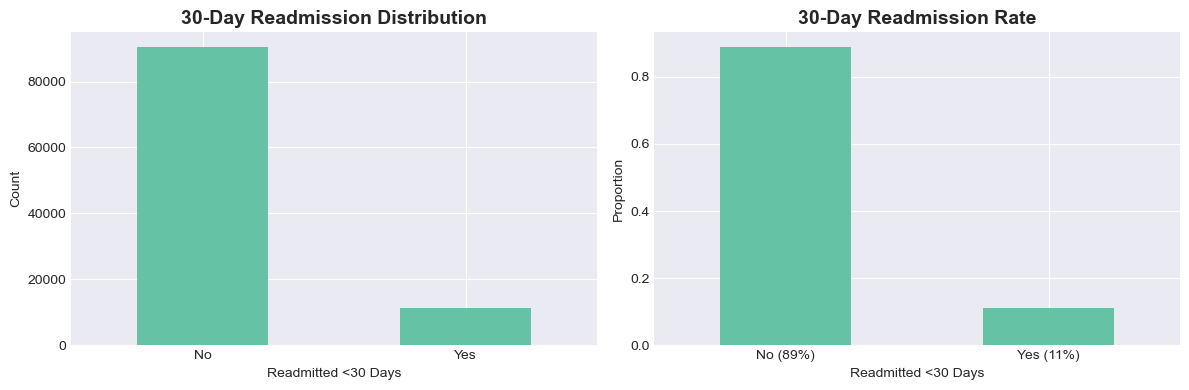

In [29]:
# Set style for professional look
sns.set_palette("Set2")
plt.style.use('seaborn-v0_8-darkgrid')

# Target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['readmit_30'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('30-Day Readmission Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Readmitted <30 Days')
ax[0].set_xticklabels(['No', 'Yes'], rotation=0)
ax[0].set_ylabel('Count')

# Percentage
df['readmit_30'].value_counts(normalize=True).plot(kind='bar', ax=ax[1])
ax[1].set_title('30-Day Readmission Rate', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Readmitted <30 Days')
ax[1].set_xticklabels(['No (89%)', 'Yes (11%)'], rotation=0)
ax[1].set_ylabel('Proportion')

plt.tight_layout()

plt.show()

### 3.2 Prior Healthcare Utilization

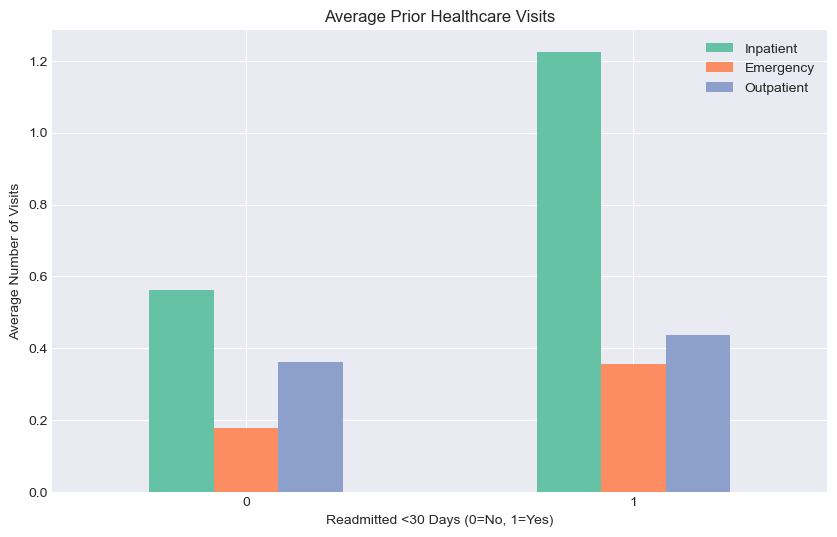

In [21]:
prior_visits = df.groupby('readmit_30')[['number_inpatient', 'number_emergency', 'number_outpatient']].mean()
prior_visits.plot(kind='bar', figsize=(10, 6))
plt.title('Average Prior Healthcare Visits')
plt.xlabel('Readmitted <30 Days (0=No, 1=Yes)')
plt.ylabel('Average Number of Visits')
plt.legend(['Inpatient', 'Emergency', 'Outpatient'])
plt.xticks(rotation=0)
plt.show()

### 3.3 Current Hospitalization Characteristics

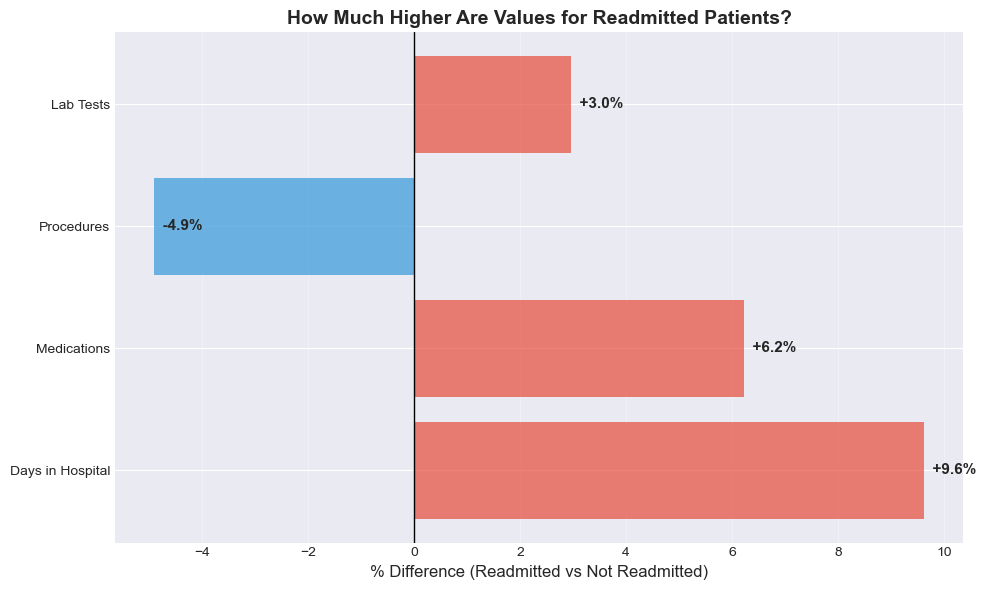

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

features = ['time_in_hospital', 'num_medications', 'num_procedures', 'num_lab_procedures']
labels = ['Days in Hospital', 'Medications', 'Procedures', 'Lab Tests']

pct_differences = []
for feature in features:
    baseline = df[df['readmit_30']==0][feature].mean()
    readmit = df[df['readmit_30']==1][feature].mean()
    pct_diff = ((readmit - baseline) / baseline) * 100
    pct_differences.append(pct_diff)

colors = ['#e74c3c' if x > 0 else '#3498db' for x in pct_differences]
bars = ax.barh(labels, pct_differences, color=colors, alpha=0.7)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('% Difference (Readmitted vs Not Readmitted)', fontsize=12)
ax.set_title('How Much Higher Are Values for Readmitted Patients?', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, pct_differences)):
    ax.text(val, i, f'  {val:+.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Care Quality Indicators

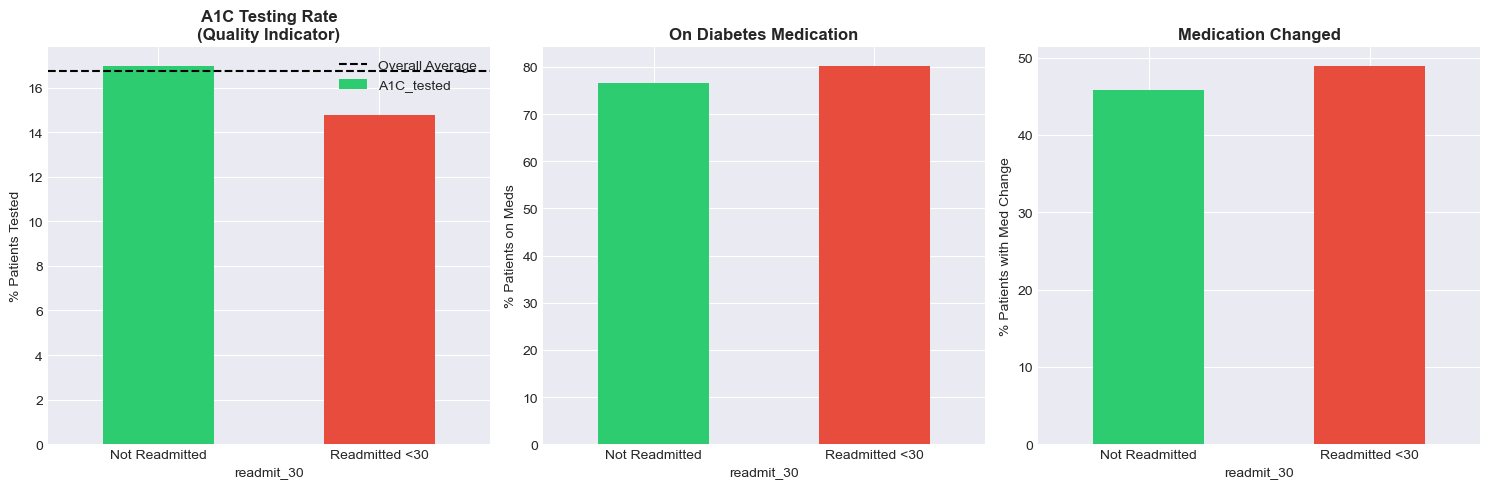

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# A1C testing rate
a1c_data = df.groupby('readmit_30')['A1C_tested'].mean() * 100
a1c_data.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('A1C Testing Rate\n(Quality Indicator)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Patients Tested')
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted <30'], rotation=0)
axes[0].axhline(y=df['A1C_tested'].mean()*100, color='black', linestyle='--', label='Overall Average')
axes[0].legend()

# On diabetes medication
diabmed_data = df.groupby('readmit_30')['diabetesMed'].apply(lambda x: (x=='Yes').sum()/len(x)*100)
diabmed_data.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('On Diabetes Medication', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Patients on Meds')
axes[1].set_xticklabels(['Not Readmitted', 'Readmitted <30'], rotation=0)

# Medication change
change_data = df.groupby('readmit_30')['change'].apply(lambda x: (x=='Ch').sum()/len(x)*100)
change_data.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Medication Changed', fontsize=12, fontweight='bold')
axes[2].set_ylabel('% Patients with Med Change')
axes[2].set_xticklabels(['Not Readmitted', 'Readmitted <30'], rotation=0)

plt.tight_layout()
plt.show()

### Age Distribution (Demographics)

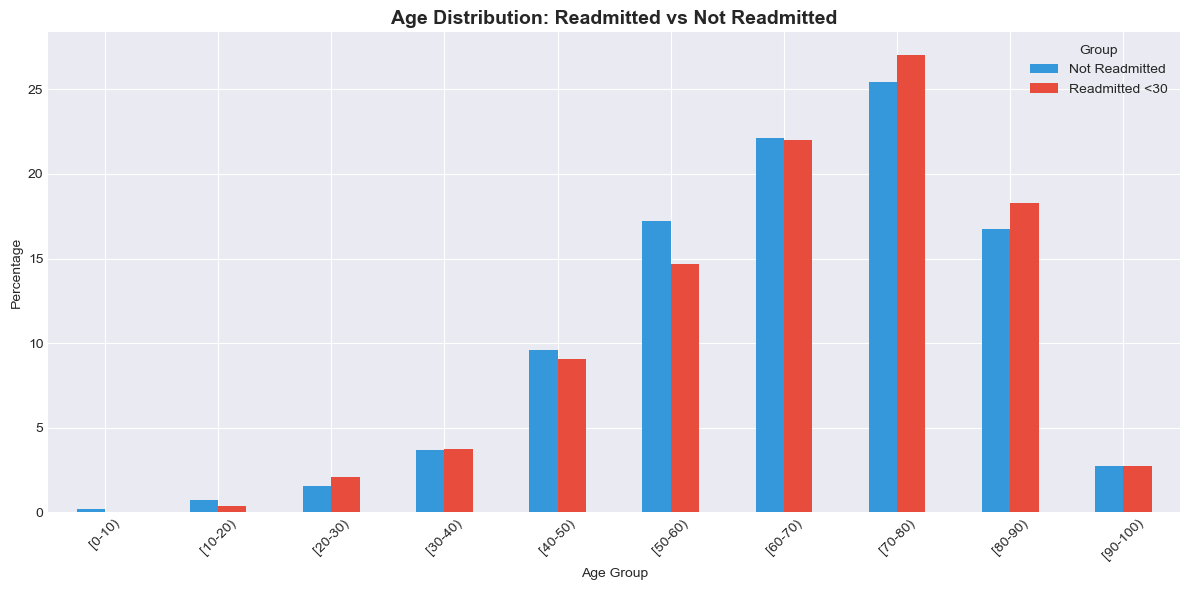

In [24]:
# Age group comparison
age_comparison = pd.crosstab(df['age'], df['readmit_30'], normalize='columns') * 100

fig, ax = plt.subplots(figsize=(12, 6))
age_comparison.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Age Distribution: Readmitted vs Not Readmitted', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage')
ax.legend(['Not Readmitted', 'Readmitted <30'], title='Group')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## 4. Key Findings

**Class Imbalance:** Only 11% of patients readmitted within 30 days - will require class balancing techniques for modeling.

**Strongest Predictor:** Prior inpatient visits (r=0.165) - "frequent flyer" (not the best term to describe these patients btw) patients are highest risk.

**Demographics:** No significant differences by age, gender, or race - readmission is not driven by demographic factors.

**Quality Gap:** Patients who received A1C testing had lower readmission rates (9.8% vs 11.4%) - this may mean the process of testing matters more than the result.

**Clinical Insight:** Current hospitalization characteristics (length of stay, medications, procedures) show minimal differences between groups. Readmission risk could be driven by patient history and care quality, not acute hospital metrics.

## 5. Next Steps

- Encode categorical variables for modeling
- Build predictive model with class balancing 